### Uso das técnicas de forecasting apresentadas em aula com Airline Passengers Dataset

#### Como o dataset aprendetado em aula (Jena Climate) possui 14 variáveis, nós precisamos adaptar o código para lidar com um dataset com apenas uma variável (número de passageiros).

In [40]:
import pandas as pd

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

print(df.head())

     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121


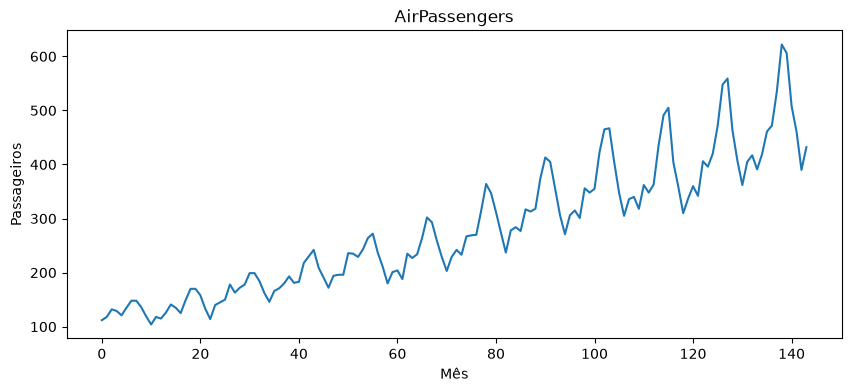

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(df["Passengers"])
plt.title("AirPassengers")
plt.xlabel("Mês")
plt.ylabel("Passageiros")
plt.show()

In [42]:
values = df["Passengers"].values.astype("float32")

raw_data = values.reshape(-1, 1).copy()

raw_data.shape

(144, 1)

In [43]:
num_train_samples = int(0.7 * len(raw_data))
num_val_samples = int(0.15 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples

print(num_train_samples)
print(num_val_samples)
print(num_test_samples)

100
21
23


### Adaptação do código de preparação dos dados para o formato de séries temporais, utilizando a função `timeseries_dataset_from_array` do Keras retirada de https://github.com/fboldt/aulasann/blob/main/aula08a_forecasting.ipynb

In [44]:
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean

std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

normalized_values = values.copy()
normalized_values = (normalized_values - mean[0]) / std[0]

In [45]:
sampling_rate = 1
sequence_length = 12
delay = 1
batch_size = 16

In [46]:
from tensorflow import keras

train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=normalized_values[delay:],
    sequence_length=sequence_length,
    sampling_rate=sampling_rate,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=normalized_values[delay:],
    sequence_length=sequence_length,
    sampling_rate=sampling_rate,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=normalized_values[delay:],
    sequence_length=sequence_length,
    sampling_rate=sampling_rate,
    shuffle=False,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples
)

### Implementação do metodo ingênuo de previsão retirada de https://github.com/fboldt/aulasann/blob/main/aula08a_forecasting.ipynb

### Baseline

In [47]:
import numpy as np

field = 0

def evaluate_naive_method(dataset):
    total_abs_err = 0
    samples_seen = 0
    for samples, targets in dataset:
        preds = samples[:, -1, field]
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen
print(f"Validation MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"Test MAE: {evaluate_naive_method(test_dataset):.2f}")

Validation MAE: 0.85
Test MAE: 0.88


### Densely connected

In [50]:
from tensorflow.keras import layers

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Flatten()(inputs)
x = layers.Dense(16, activation='relu')(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint('jena_dense.keras', save_best_only=True)
]
model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)
model = keras.models.load_model('jena_dense.keras')
print(f'Test MAE: {model.evaluate(test_dataset)[1]:.2f}')

Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.9519 - mae: 0.7798 - val_loss: 1.9684 - val_mae: 1.1575
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.5654 - mae: 0.6173 - val_loss: 1.3773 - val_mae: 0.9779
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3815 - mae: 0.5116 - val_loss: 1.0986 - val_mae: 0.8957
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2676 - mae: 0.4272 - val_loss: 0.8741 - val_mae: 0.8040
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1922 - mae: 0.3537 - val_loss: 0.7566 - val_mae: 0.7411
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1503 - mae: 0.3050 - val_loss: 0.6899 - val_mae: 0.7020
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1262 - mae: 0.2725 - val_loss: 0.6704 - val_mae: 0.6979
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1137 - mae: 0.2532 - val_loss: 0.6133 - val_mae: 0.6664
Epoch 9/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1023 - mae: 0.2390 - 